# Lab 1 - Pipeline de adquisicion y analisis de textos
Notebook de trabajo para capturar textos desde X y RSS, consolidarlos, preprocesarlos y analizar resultados.

## Librerias principales
pandas, requests, feedparser, pyarrow, nltk, scikit-learn, pymongo, matplotlib.

In [31]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
from pathlib import Path
import sys
from getpass import getpass
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "config.py").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from config import (
    X_QUERY,
    X_MAX_RESULTS,
    COOPERATIVA_RSS_URL,
    COOPERATIVA_MAX_ITEMS,
    PARQUET_OUTPUT_NAME,
    PICKLE_OUTPUT_NAME,
)
from procesamiento.x_api import buscar_posts_x
from procesamiento.rss import leer_rss
from fuentes.consolidacion import consolidar_dataframes
from fuentes.limpieza import limpiar_texto
from fuentes.analisis import obtener_frecuencias, aplicar_tfidf, aplicar_kmeans, aplicar_pca
from persistencia.binaria import guardar_binario

In [33]:
bearer = getpass("Bearer Token de X (si aun no lo tienes, Enter temporal): ").strip()
if bearer:
    df_x = buscar_posts_x(X_QUERY, bearer, X_MAX_RESULTS)
else:
    print("[PENDIENTE] Ejecutando temporalmente sin X. Cuando tengas Bearer, vuelve a correr desde esta celda.")
    df_x = pd.DataFrame(columns=["id", "fuente", "texto", "fecha", "autor", "url", "consulta"])

df_coop = leer_rss(COOPERATIVA_RSS_URL, "Cooperativa", COOPERATIVA_MAX_ITEMS)

print(f"X: {len(df_x)} filas")
print(f"Cooperativa: {len(df_coop)} filas")

X: 99 filas
Cooperativa: 15 filas


### Cargar fuente opcional desde CSV (TikTok)
Aquí puedes cargar una fuente adicional desde archivo CSV. El notebook intentará detectar automáticamente columnas de texto, ID, fecha, etc.

In [34]:
from fuentes.csv import cargar_csv_flexible
from pathlib import Path

# Buscar archivos CSV en data/raw/
csv_path = Path("../data/raw/fuente_opcional.csv")

if csv_path.exists():
    df_opcional = cargar_csv_flexible(str(csv_path), nombre_fuente="Opcional")
    print(f"CSV cargado: {len(df_opcional)} registros")
    print(f"Columnas: {list(df_opcional.columns)}")
else:
    print(f"[INFO] No se encontró {csv_path}")
    print("       Para agregar una fuente, coloca un CSV en data/raw/fuente_opcional.csv")
    df_opcional = pd.DataFrame(columns=["id", "fuente", "texto", "fecha", "autor", "url", "consulta"])

[INFO] No se encontró ..\data\raw\fuente_opcional.csv
       Para agregar una fuente, coloca un CSV en data/raw/fuente_opcional.csv


In [35]:
df_corpus = consolidar_dataframes([df_x, df_coop, df_opcional])
if df_corpus.empty:
    raise ValueError("No se obtuvieron textos desde las fuentes.")

df_corpus = df_corpus.reset_index(drop=True)
print(f"[OK] Corpus consolidado: {len(df_corpus)} registros")
print(f"     Distribución por fuente:\n{df_corpus['fuente'].value_counts()}")
df_corpus.head()

[OK] Corpus consolidado: 114 registros
     Distribución por fuente:
fuente
X              99
Cooperativa    15
Name: count, dtype: int64


,id,fuente,texto,fecha,autor,url,consulta
0,2048419196309012645,X,@jereragusa Hay que dejarse auditar si no sos ...,2026-04-26T15:09:28.000Z,1528905006778355713,None,universidad OR educacion OR tecnologia lang:es...
1,2048419178248298667,X,@adelaidosa_ Y terminó con un rotundo Universi...,2026-04-26T15:09:24.000Z,1779347300818501632,None,universidad OR educacion OR tecnologia lang:es...
2,2048418895812231675,X,Señores la mujer de Jey one su universidad des...,2026-04-26T15:08:17.000Z,1038651034011402240,None,universidad OR educacion OR tecnologia lang:es...
3,2048418883975962679,X,"@bobsparz @LelisChoque Calla conchatumadre, cu...",2026-04-26T15:08:14.000Z,1328410774998573056,None,universidad OR educacion OR tecnologia lang:es...
4,2048418865709814032,X,Ayer estaba recordando mis tiempos de universi...,2026-04-26T15:08:10.000Z,21620110,None,universidad OR educacion OR tecnologia lang:es...


In [36]:
df_corpus["texto_limpio"] = df_corpus["texto"].apply(limpiar_texto)
frecuencias = obtener_frecuencias(df_corpus["texto_limpio"].tolist())
pd.DataFrame(frecuencias.most_common(20), columns=["token", "frecuencia"])

,token,frecuencia
0,strong,334
1,p,248
2,universidad,87
3,em,40
4,h,30
5,href,26
6,rel,22
7,link,22
8,nota,22
9,target,22


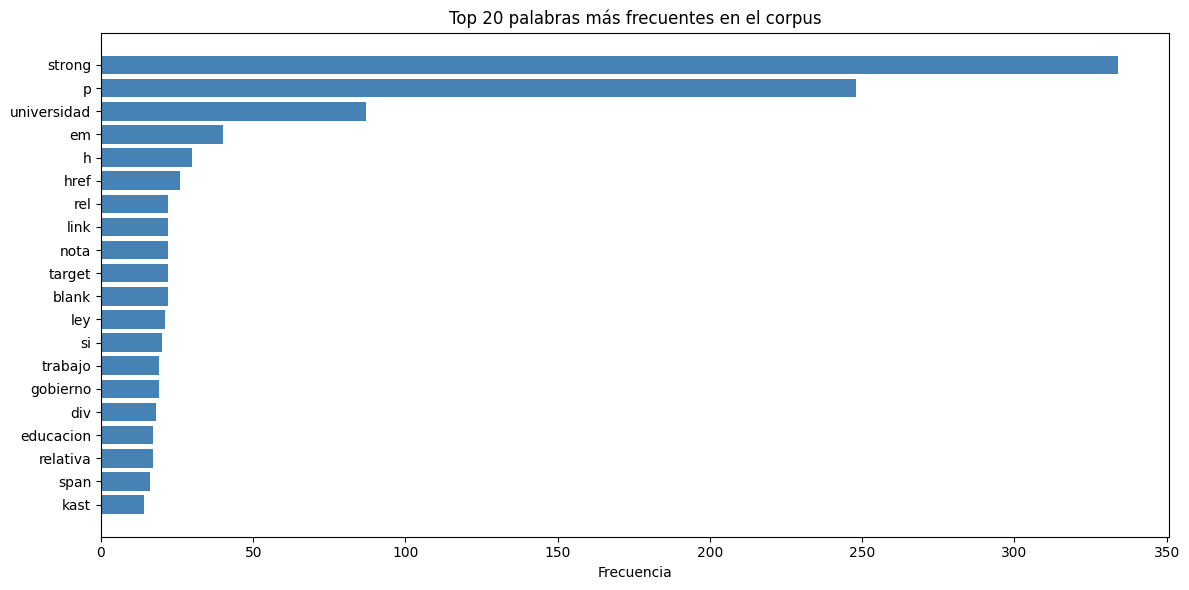

Total palabras únicas: 2547


In [37]:
import matplotlib.pyplot as plt

# Gráfico de palabras más frecuentes
fig, ax = plt.subplots(figsize=(12, 6))
palabras, freq = zip(*frecuencias.most_common(20))
ax.barh(palabras, freq, color='steelblue')
ax.set_xlabel('Frecuencia')
ax.set_title('Top 20 palabras más frecuentes en el corpus')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Total palabras únicas: {len(frecuencias)}")

In [25]:
X_tfidf, vectorizer = aplicar_tfidf(df_corpus)
df_corpus, modelo_kmeans = aplicar_kmeans(X_tfidf, df_corpus)
df_corpus = aplicar_pca(X_tfidf, df_corpus)

df_corpus[["fuente", "cluster", "pca_1", "pca_2"]].head()

,fuente,cluster,pca_1,pca_2
0,X,2,-0.071027,0.002130
1,X,2,-0.047847,-0.191508
2,X,1,-0.076620,-0.226639
3,X,2,-0.057596,0.029233
4,X,3,-0.082100,-0.015249


### Visualización de resultados con PCA

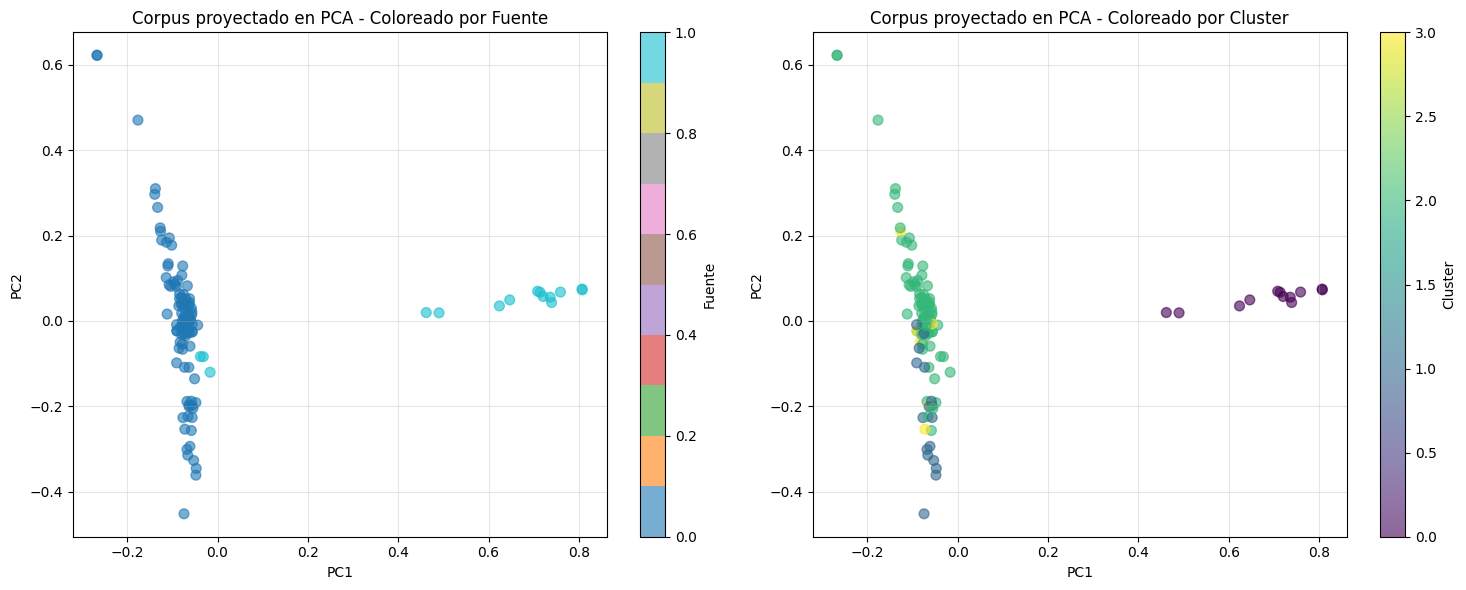

Distribución en clusters: {0: 12, 1: 17, 2: 78, 3: 7}


In [26]:
# Gráficos PCA - Coloreado por Fuente
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Colores por fuente
fuentes_unicas = df_corpus['fuente'].unique()
colores_fuente = {fuente: i for i, fuente in enumerate(fuentes_unicas)}
colores1 = [colores_fuente[fuente] for fuente in df_corpus['fuente']]

# Gráfico 1: PCA coloreado por Fuente
scatter1 = ax1.scatter(df_corpus['pca_1'], df_corpus['pca_2'], c=colores1, cmap='tab10', alpha=0.6, s=50)
ax1.set_xlabel(f'PC1')
ax1.set_ylabel(f'PC2')
ax1.set_title('Corpus proyectado en PCA - Coloreado por Fuente')
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=ax1, label='Fuente')

# Gráfico 2: PCA coloreado por Cluster
scatter2 = ax2.scatter(df_corpus['pca_1'], df_corpus['pca_2'], c=df_corpus['cluster'], cmap='viridis', alpha=0.6, s=50)
ax2.set_xlabel(f'PC1')
ax2.set_ylabel(f'PC2')
ax2.set_title('Corpus proyectado en PCA - Coloreado por Cluster')
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=ax2, label='Cluster')

plt.tight_layout()
plt.show()

print(f"Distribución en clusters: {df_corpus['cluster'].value_counts().sort_index().to_dict()}")

In [28]:
from fuentes.analisis import obtener_terminos_cluster

# Obtener términos representativos por cluster
terminos_por_cluster = obtener_terminos_cluster(vectorizer, modelo_kmeans, top_k=10)

print("=" * 70)
print("TÉRMINOS MÁS REPRESENTATIVOS POR CLUSTER")
print("=" * 70)
for cluster_name, terminos in terminos_por_cluster.items():
    print(f"\n{cluster_name}:")
    print(f"  {', '.join(terminos)}")
print("\n" + "=" * 70)

TÉRMINOS MÁS REPRESENTATIVOS POR CLUSTER

Cluster 0:
  strong, em, href, div, link, target, blank, rel, nota, gobierno

Cluster 1:
  educacion, gente, quieren, va, solo, si, crianza, juntos, tan, general

Cluster 2:
  universidad, chile, tecnologia, hoy, años, nunca, tiempo, ser, pública, casa

Cluster 3:
  cuenta, filosofía, bajo, da, universidad, claro, negativos, muro, aspectos, sovietica



In [29]:
guardar_binario(df_corpus, PARQUET_OUTPUT_NAME, PICKLE_OUTPUT_NAME)
print(f"Parquet guardado en: {PARQUET_OUTPUT_NAME}")
print(f"Pickle guardado en: {PICKLE_OUTPUT_NAME}")

Parquet guardado en: data/corpus.parquet
Pickle guardado en: data/corpus.pkl


In [30]:
from config import MONGO_DB_NAME, MONGO_COLLECTION_NAME
from persistencia.mongodb import guardar_en_mongodb

mongo_uri = getpass("Mongo URI (requerida para guardar en MongoDB): ").strip()
if not mongo_uri:
    print("[PENDIENTE] Aun no hay Mongo URI. Ejecuta esta celda cuando la tengas.")
else:
    resumen_mongo = guardar_en_mongodb(df_corpus, mongo_uri, MONGO_DB_NAME, MONGO_COLLECTION_NAME)
    print("Resumen MongoDB:", resumen_mongo)

[PENDIENTE] Aun no hay Mongo URI. Ejecuta esta celda cuando la tengas.


## Nota
Con Bearer disponible, vuelve a ejecutar desde la celda 5 para incorporar X y luego guardar el corpus final en MongoDB.

## Preguntas guía para análisis de resultados

1. **¿Qué palabras aparecen con mayor frecuencia en todo el corpus?**
   - ¿Reflejan temas específicos sobre educación, tecnología o universidad?

2. **¿Qué diferencias léxicas se observan entre las fuentes (X, Cooperativa, etc.)?**
   - ¿Cada fuente tiene vocabulario particular?

3. **¿Los clusters encontrados parecen coherentes con los temas presentes?**
   - ¿Qué palabras definen cada cluster?

4. **¿El gráfico PCA sugiere separación clara entre fuentes o grupos?**
   - ¿Hay clusters bien definidos o solapados?

5. **¿Qué ventajas ofrece Parquet frente a CSV en este laboratorio?**
   - ¿Cómo mejora la compresión y velocidad de lectura?

6. **¿Qué aporta MongoDB cuando el corpus crece y necesita persistencia flexible?**
   - ¿Cómo facilita las consultas sin esquema fijo?

In [26]:
print("=" * 70)
print("ESTADÍSTICAS FINALES DEL CORPUS")
print("=" * 70)
print(f"\nDocumentos totales: {len(df_corpus)}")
print(f"Palabras únicas (después de limpieza): {len(frecuencias)}")
print(f"\nDistribución por fuente:")
print(df_corpus['fuente'].value_counts())
print(f"\nDistribución por cluster:")
print(df_corpus['cluster'].value_counts().sort_index())
print(f"\nLongitud promedio de texto (caracteres): {df_corpus['texto'].str.len().mean():.0f}")
print(f"Rango: {df_corpus['texto'].str.len().min():.0f} - {df_corpus['texto'].str.len().max():.0f}")
print(f"\nArchivos guardados:")
print(f"  - Parquet: {PARQUET_OUTPUT_NAME}")
print(f"  - Pickle: {PICKLE_OUTPUT_NAME}")
print(f"  - MongoDB: {MONGO_DB_NAME}.{MONGO_COLLECTION_NAME}")
print("\n" + "=" * 70)

ESTADÍSTICAS FINALES DEL CORPUS

Documentos totales: 114
Palabras únicas (después de limpieza): 2617

Distribución por fuente:
fuente
X              99
Cooperativa    15
Name: count, dtype: int64

Distribución por cluster:
cluster
0     6
1    82
2    10
3    16
Name: count, dtype: int64

Longitud promedio de texto (caracteres): 583
Rango: 36 - 10310

Archivos guardados:
  - Parquet: data/corpus.parquet
  - Pickle: data/corpus.pkl
  - MongoDB: LaboratorioML.corpus_textos

